# Clustering: Finding Groups in Unlabeled Data
Clustering is the task of grouping similar data points together without predefined labels. Unlike prediction models, clustering doesn't have a "ground truth" — we're trying to discover natural patterns in data.

Three major approaches exist: **KMeans** (partitioning), **KNN** (density-based local neighborhoods), and **SVM** (support vectors for classification that can be adapted for clustering).

The challenge: How do we know if our clustering is good without labels? And how do different algorithms handle different data shapes?

<details>

<summary>Clustering vs Classification</summary>
Classification: You have labeled training data and predict labels for new data.<br><br>
Clustering: You have unlabeled data and discover group structure. The "best" clustering depends on your definition of similarity. Different algorithms find different structures—that's not a bug, it's a feature!
</details>

## The Problem: Customer Segmentation
Imagine you run an e-commerce platform and have data on 1000 customers: their purchase frequency, average order value, and browsing time. You have no pre-assigned customer types, but you want to find natural groups so you can tailor marketing.

Let's generate synthetic customer data and visualize it:

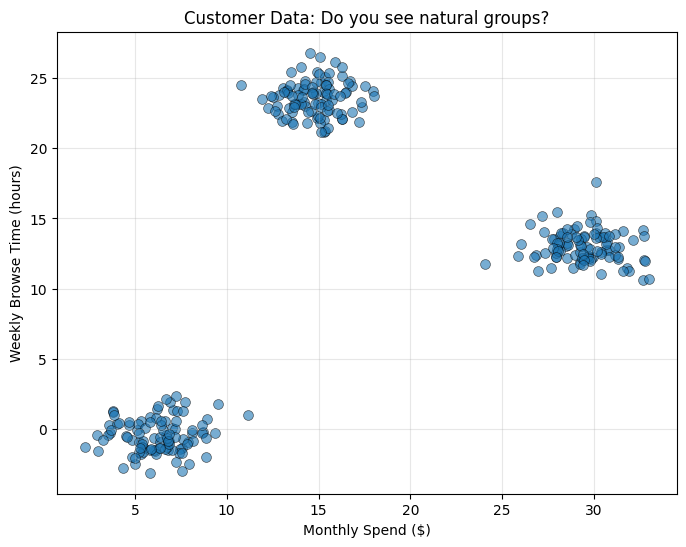

Dataset shape: (300, 2)
Feature ranges - Spend: [2.3, 33.0]
Feature ranges - Browse: [-3.1, 26.8]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Generate 3 natural customer clusters
# Cluster 1: "Browsers" (low spend, high browse time)
# Cluster 2: "Regular Shoppers" (medium spend, medium engage)
# Cluster 3: "VIP Buyers" (high spend, low browser time - they know what they want)

X, y_true = make_blobs(n_samples=300, centers=3, n_features=2, 
                        cluster_std=0.8, random_state=42)

# Relabel axes for interpretation
X[:, 0] = X[:, 0] * 2 + 20  # Purchase frequency (dollars per month)
X[:, 1] = X[:, 1] * 1.5 + 10  # Browsing time (hours per week)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.xlabel('Monthly Spend ($)')
plt.ylabel('Weekly Browse Time (hours)')
plt.title('Customer Data: Do you see natural groups?')
plt.grid(alpha=0.3)
plt.show()

print(f"Dataset shape: {X.shape}")
print(f"Feature ranges - Spend: [{X[:, 0].min():.1f}, {X[:, 0].max():.1f}]")
print(f"Feature ranges - Browse: [{X[:, 1].min():.1f}, {X[:, 1].max():.1f}]")

## KMeans: Partitioning by Centroid Distance
**KMeans** is the simplest and most popular clustering algorithm. The idea:
1. Pick K random points as cluster centers (centroids)
2. Assign each point to the nearest centroid
3. Recalculate centroids as the mean of assigned points
4. Repeat steps 2-3 until convergence

It assumes clusters are roughly **spherical** and **similar-sized**. Let's implement it from scratch to understand the mechanism:

Converged at iteration 2
Converged at iteration 5


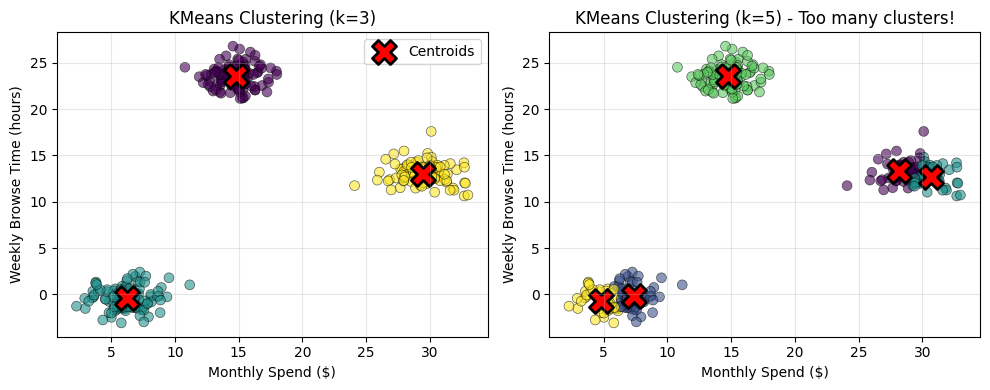

Cluster sizes: [100 100 100]


In [8]:
class SimpleKMeans:
    def __init__(self, k=3, max_iter=100):
        self.k = k
        self.max_iter = max_iter
        self.centroids = None
        self.labels = None
    
    def fit(self, X):
        # 1. Initialize: randomly pick k points from data as centroids
        np.random.seed(42)
        idx = np.random.choice(len(X), self.k, replace=False)
        self.centroids = X[idx].copy()
        
        for iteration in range(self.max_iter):
            # 2. Assignment step: assign each point to nearest centroid
            distances = np.zeros((len(X), self.k))
            for j in range(self.k):
                distances[:, j] = np.linalg.norm(X - self.centroids[j], axis=1)
            
            self.labels = np.argmin(distances, axis=1)
            
            # 3. Update step: recalculate centroids
            old_centroids = self.centroids.copy()
            for j in range(self.k):
                self.centroids[j] = X[self.labels == j].mean(axis=0)
            
            # Check for convergence
            if np.allclose(old_centroids, self.centroids):
                print(f"Converged at iteration {iteration}")
                break
        
        return self
    
    def predict(self, X):
        distances = np.zeros((len(X), self.k))
        for j in range(self.k):
            distances[:, j] = np.linalg.norm(X - self.centroids[j], axis=1)
        return np.argmin(distances, axis=1)

# Fit KMeans with k=3
kmeans = SimpleKMeans(k=3, max_iter=100)
kmeans.fit(X)

# Visualize
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels, cmap='viridis', 
                       alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c='red', 
           marker='X', s=300, edgecolors='black', linewidth=2, label='Centroids')
plt.xlabel('Monthly Spend ($)')
plt.ylabel('Weekly Browse Time (hours)')
plt.title('KMeans Clustering (k=3)')
plt.legend()
plt.grid(alpha=0.3)

# Show the effect of wrong k
plt.subplot(1, 2, 2)
kmeans_wrong = SimpleKMeans(k=5, max_iter=100)
kmeans_wrong.fit(X)
scatter = plt.scatter(X[:, 0], X[:, 1], c=kmeans_wrong.labels, cmap='viridis', 
                       alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.scatter(kmeans_wrong.centroids[:, 0], kmeans_wrong.centroids[:, 1], c='red', 
           marker='X', s=300, edgecolors='black', linewidth=2)
plt.xlabel('Monthly Spend ($)')
plt.ylabel('Weekly Browse Time (hours)')
plt.title('KMeans Clustering (k=5) - Too many clusters!')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Cluster sizes: {np.bincount(kmeans.labels)}")

<details>

<summary>Why does KMeans fail on non-spherical data?</summary>
KMeans minimizes within-cluster variance (sum of squared distances to centroid). This creates spherical clusters because it's optimizing for Euclidean distance. If your true clusters are crescent-shaped or nested, KMeans will artificially split or merge them. The algorithm assumes clusters have similar density and size—violate that assumption and results degrade.
</details>

## The Limitation: KMeans Struggles with Non-Spherical Shapes
Let's test KMeans on data where clusters aren't spherical:

Converged at iteration 7


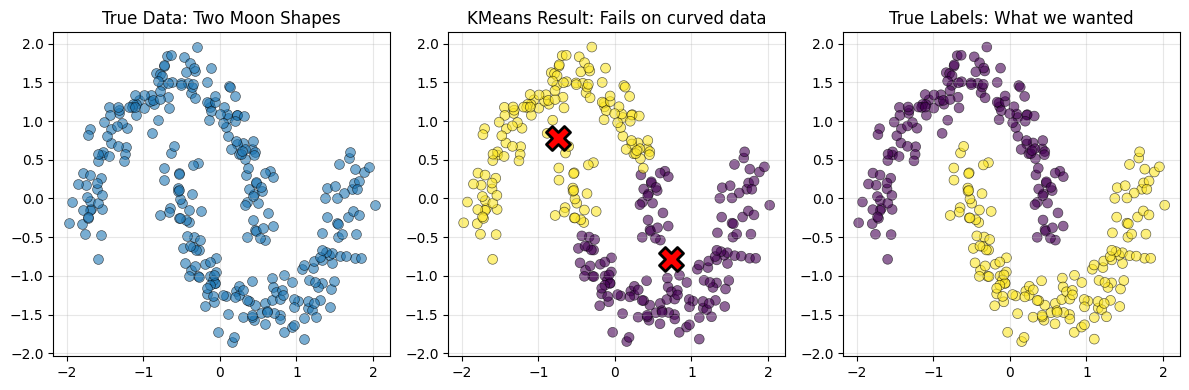

Question: Why does KMeans split the moon shapes? What assumption is it making?


In [9]:
# Generate moon-shaped clusters (non-convex)
X_moons, y_moons = make_moons(n_samples=300, noise=0.1, random_state=42)
X_moons = StandardScaler().fit_transform(X_moons)

# Try KMeans
kmeans_moon = SimpleKMeans(k=2, max_iter=100)
kmeans_moon.fit(X_moons)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X_moons[:, 0], X_moons[:, 1], alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.title('True Data: Two Moon Shapes')
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=kmeans_moon.labels, cmap='viridis', 
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.scatter(kmeans_moon.centroids[:, 0], kmeans_moon.centroids[:, 1], c='red', 
           marker='X', s=300, edgecolors='black', linewidth=2)
plt.title('KMeans Result: Fails on curved data')
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', 
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.title('True Labels: What we wanted')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Question: Why does KMeans split the moon shapes? What assumption is it making?")

## KNN-based Clustering: Density and Locality Matter
**KNN (K-Nearest Neighbors) clustering** uses a different logic: points that are locally dense and close together should be in the same cluster. The **DBSCAN** algorithm (Density-Based Spatial Clustering) uses KNN principles.

Core idea:
- If a point has at least `min_pts` neighbors within radius `eps`, it's a **core point**
- Core points that are reachable from each other form a cluster
- Isolated points become **noise** (not forced into a cluster)

This handles arbitrary shapes and doesn't require specifying K!

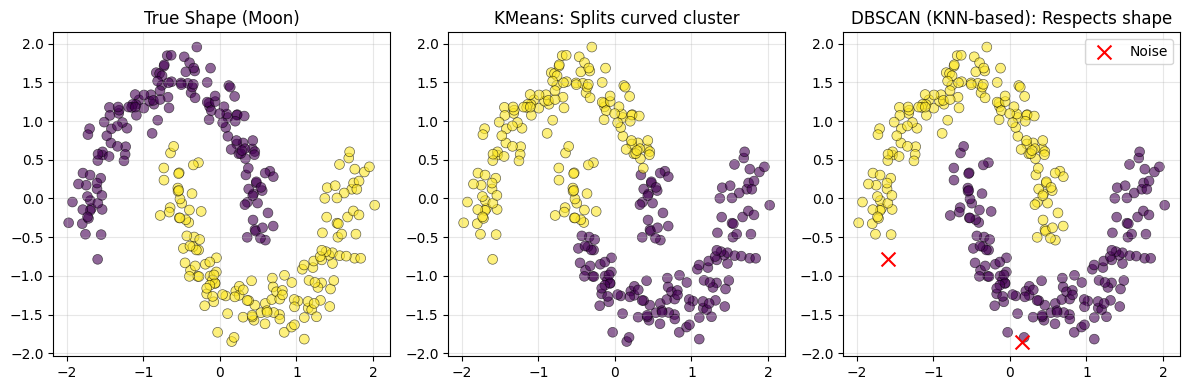

DBSCAN found 2 clusters
Noise points: 2


In [10]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# For moon data, DBSCAN should work better
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_moons)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', 
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.title('True Shape (Moon)')
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=kmeans_moon.labels, cmap='viridis', 
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.title('KMeans: Splits curved cluster')
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
# Noise points (label -1) in black
mask_noise = labels_dbscan == -1
plt.scatter(X_moons[~mask_noise, 0], X_moons[~mask_noise, 1], 
           c=labels_dbscan[~mask_noise], cmap='viridis', 
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.scatter(X_moons[mask_noise, 0], X_moons[mask_noise, 1], 
           c='red', marker='x', s=100, label='Noise')
plt.title('DBSCAN (KNN-based): Respects shape')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"DBSCAN found {len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)} clusters")
print(f"Noise points: {np.sum(labels_dbscan == -1)}")

<details>

<summary>KNN vs KMeans: Key Differences</summary>
**KMeans**: Minimizes distance to cluster center. Assumes K clusters exist. Works on convex, similar-sized clusters.<br><br>
**DBSCAN (KNN-based)**: Groups points by local density. Doesn't assume K in advance. Handles arbitrary shapes and identifies noise. Requires tuning `eps` and `min_samples`.
</details>

## SVM for Clustering: One-Class Approach
**One-Class SVM** is less common for clustering but important conceptually. It learns a boundary around the data, treating points inside as the cluster and outside as anomalies.

Unlike KMeans and DBSCAN, One-Class SVM uses a non-linear kernel to potentially capture complex cluster boundaries.

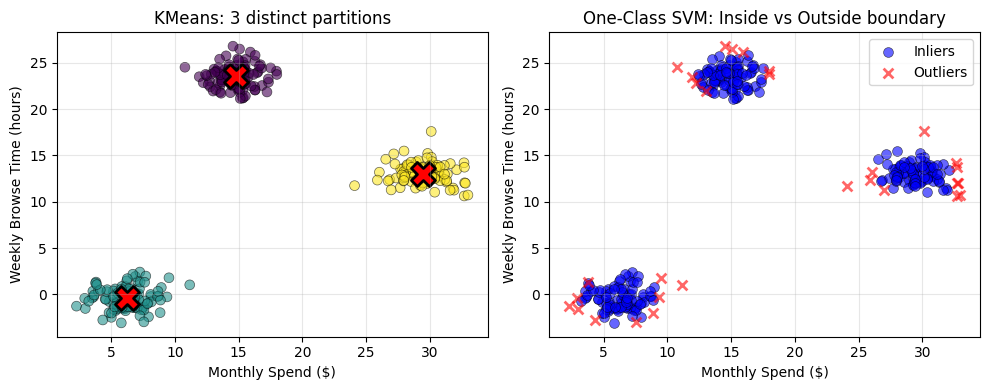

One-Class SVM flagged 30 points as outliers
Note: One-Class SVM doesn't partition into multiple clusters—it defines an 'inside' boundary.


In [11]:
from sklearn.svm import OneClassSVM

# One-Class SVM for the spherical data
oc_svm = OneClassSVM(kernel='rbf', gamma=0.01, nu=0.1)  # nu = fraction of outliers
labels_svm = oc_svm.fit_predict(X)  # Returns 1 for inliers, -1 for outliers

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels, cmap='viridis', 
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c='red', 
           marker='X', s=300, edgecolors='black', linewidth=2)
plt.xlabel('Monthly Spend ($)')
plt.ylabel('Weekly Browse Time (hours)')
plt.title('KMeans: 3 distinct partitions')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
mask_inlier = labels_svm == 1
plt.scatter(X[mask_inlier, 0], X[mask_inlier, 1], c='blue', 
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5, label='Inliers')
plt.scatter(X[~mask_inlier, 0], X[~mask_inlier, 1], c='red', 
           alpha=0.6, s=50, marker='x', linewidth=2, label='Outliers')
plt.xlabel('Monthly Spend ($)')
plt.ylabel('Weekly Browse Time (hours)')
plt.title('One-Class SVM: Inside vs Outside boundary')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"One-Class SVM flagged {np.sum(labels_svm == -1)} points as outliers")
print("Note: One-Class SVM doesn't partition into multiple clusters—it defines an 'inside' boundary.")

## Evaluating Clustering Without True Labels
How do we judge clustering quality without ground truth? Common metrics:

1. **Silhouette Score**: Measures cohesion (points close to their cluster) vs separation (clusters far apart). Range [-1, 1]; higher is better.
2. **Inertia**: Sum of squared distances to nearest centroid. Lower is better, but biased toward more clusters.
3. **Davies-Bouldin Index**: Ratio of within-cluster to between-cluster distances. Lower is better.

These are proxies; they may not match your domain understanding of "good" clusters.

Converged at iteration 1
k=2: Silhouette=0.705, Davies-Bouldin=0.445
Converged at iteration 2
k=3: Silhouette=0.879, Davies-Bouldin=0.169
Converged at iteration 3
k=4: Silhouette=0.709, Davies-Bouldin=0.573
Converged at iteration 5
k=5: Silhouette=0.532, Davies-Bouldin=0.845
Converged at iteration 9
k=6: Silhouette=0.529, Davies-Bouldin=0.825
Converged at iteration 9
k=7: Silhouette=0.511, Davies-Bouldin=0.862
Converged at iteration 14
k=8: Silhouette=0.523, Davies-Bouldin=0.794
Converged at iteration 14
k=9: Silhouette=0.524, Davies-Bouldin=0.810
Converged at iteration 14
k=10: Silhouette=0.541, Davies-Bouldin=0.760


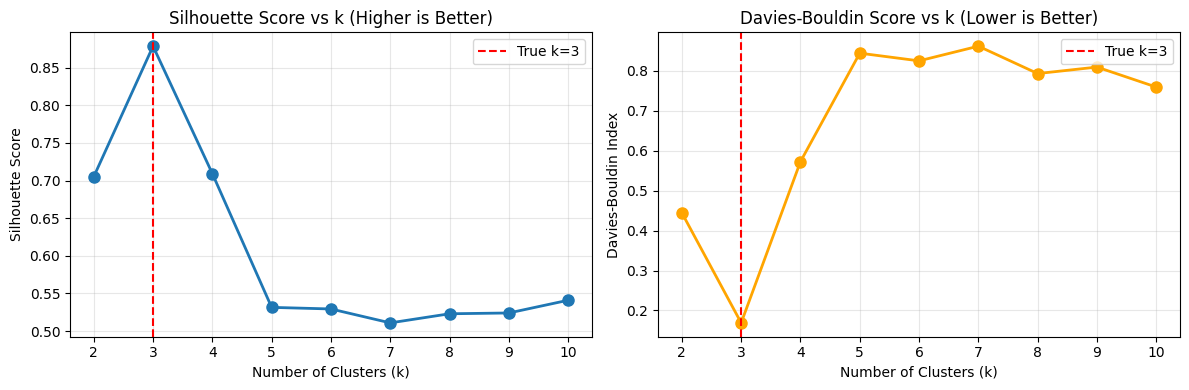

In [12]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Compare silhouette scores for different k values
silhouette_scores = []
davies_bouldin_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans_test = SimpleKMeans(k=k, max_iter=100)
    kmeans_test.fit(X)
    sil_score = silhouette_score(X, kmeans_test.labels)
    db_score = davies_bouldin_score(X, kmeans_test.labels)
    silhouette_scores.append(sil_score)
    davies_bouldin_scores.append(db_score)
    print(f"k={k}: Silhouette={sil_score:.3f}, Davies-Bouldin={db_score:.3f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_values, silhouette_scores, 'o-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', label='True k=3')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs k (Higher is Better)')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(k_values, davies_bouldin_scores, 'o-', linewidth=2, markersize=8, color='orange')
plt.axvline(x=3, color='red', linestyle='--', label='True k=3')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Score vs k (Lower is Better)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<details>

<summary>Elbow Method vs Silhouette</summary>
**Elbow Method**: Plot inertia vs k, look for the "elbow" (diminishing returns). Intuitive but subjective.<br><br>
**Silhouette Score**: More objective metric combining cohesion and separation. Favors compact, well-separated clusters. May prefer smaller k values.
</details>

## Summary: Algorithm Comparison

| Algorithm | Assumption | Pros | Cons | Use Case |
|-----------|-----------|------|------|----------|
| **KMeans** | Spherical, similar-sized | Fast, scalable, interpretable | Fixed k, sensitive to init, bad on curved data | When you know k and data is well-separated |
| **DBSCAN** | Local density | Arbitrary shapes, finds noise, no k needed | Sensitive to eps/min_samples, slow on high-D | Non-convex shapes, robust outlier handling |
| **One-Class SVM** | Boundary definition | Non-linear boundaries, anomaly detection | Only binary (in/out), harder to interpret | Outlier/anomaly detection |

**Key Takeaway**: Clustering is subjective. Different algorithms encode different notions of "similarity." KMeans assumes distance-based spherical clusters; DBSCAN assumes density-based neighborhoods; One-Class SVM defines a data-enclosing boundary. Choose based on your domain knowledge of what "natural groups" should look like.

## Strengths and Weaknesses

### Strengths
- **No labels required**: Unsupervised, so applicable when labeling is expensive
- **Interpretability**: Cluster centers/boundaries are explainable
- **Scalability**: KMeans is O(nkd) per iteration; efficient for large datasets
- **Multiple perspectives**: Different algorithms reveal different cluster structures

### Weaknesses
- **No ground truth**: Evaluation is heuristic; hard to validate if clusters are "right"
- **Curse of dimensionality**: Distance metrics become less meaningful in high dimensions
- **Hyperparameter sensitivity**: KMeans depends on k, DBSCAN on eps/min_samples, SVM on kernel/gamma
- **Scalability limits**: Some algorithms (DBSCAN, SVM) struggle in very high dimensions or on massive datasets
- **No causality**: Clusters correlate; they don't explain why groups exist